<a href="https://colab.research.google.com/github/BaeJinYeong01/-/blob/main/Process_Efficiency_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 문제
실습 2. 불량률 계산(심화)

A, B, C, D, E 다섯개의 순차적인 공정을 통해 제품을 조립하는 생산라인이 있다. 품질팀에서 제공해 준 각 공정별 불량품 현황을 바탕으로, 생산팀장의 입장에서 반별 공정효율성을 구해보시오.

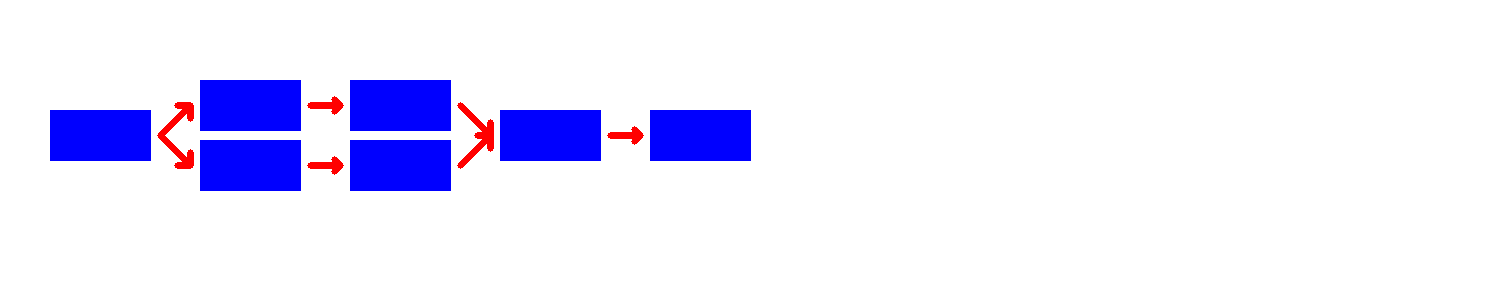

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Necessary import if we are working in Google Colab. Otherwise,
# if will use cv2.imshow(), this import is not required.
from google.colab.patches import cv2_imshow

img = np.zeros((300, 1500, 3), dtype="uint8")
img[:] = (255,255,255)
cv2.rectangle(img, (50,110), (150,160), (255,0,0), (-1))


cv2.arrowedLine(img, (160,135), (190,105), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,80), (300,130), (255,0,0), (-1))
cv2.arrowedLine(img, (310,105), (340,105), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,80), (450,130), (255,0,0), (-1))
cv2.arrowedLine(img, (460,105), (490,135), (0,0,255), (5), 8,0,0.3)

cv2.arrowedLine(img, (160,135), (190,165), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,140), (300,190), (255,0,0), (-1))
cv2.arrowedLine(img, (310,165), (340,165), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,140), (450,190), (255,0,0), (-1))
cv2.arrowedLine(img, (460,165), (490,135), (0,0,255), (5), 8,0,0.3)


cv2.rectangle(img, (500,110), (600,160), (255,0,0), (-1))
cv2.arrowedLine(img, (610,135), (640,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,110), (750,160), (255,0,0), (-1))
cv2_imshow(img)

# 접근 방법

각 공정을 동시에 시작할 수 있기 때문에 공정별로 걸리는 시간을 비슷하게 만들면 공정효율성을 높일 수 있습니다. 공정당 완성품을 만드는 데 걸리는 기대 소요시간은 불량률에 영향을 받으므로 공정별 기대 소요시간을 구할 때 이 불량률 부분을 미리 고려해야 합니다.

1. 불량품이 없다고 가정하고 공정별 평균시간을 구합니다.

2. 투입량 대비 산출량으로 각 공정의 불량률을 계산합니다.

3. 공정별 기대 소요시간을 구합니다.

4. 공정 효율성을 구합니다.






# 1. 불량품이 없다고 가정하고 공정별 평균 소요시간을 구합니다.


데이터를 먼저 읽어들입니다.

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving exercise_2_advanced.xlsx to exercise_2_advanced.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io
df = pd.read_excel(io.BytesIO(uploaded['exercise_2_advanced.xlsx']))
df



,A Process,B1 Process,C1 Process,B2 Process,C2 Process,D Process,E Process,A NG,B1 NG,C1 NG,B2 NG,C2 NG,D NG,E NG
0,2.835493,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.0,0.0,NaN,NaN,0,0
1,2.969695,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.0,0.0,NaN,NaN,0,0
2,2.957402,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.0,0.0,NaN,NaN,0,0
3,2.673891,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.0,0.0,NaN,NaN,0,0
4,3.046558,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.0,0.0,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.005258,2.117503,0.0,1.992871,5.237895,0.0,3.757049,1,NaN,NaN,1.0,1.0,1,1
19996,3.030712,2.233766,0.0,1.929842,4.890443,0.0,4.014973,1,NaN,NaN,1.0,1.0,1,1
19997,3.064119,2.159472,0.0,1.928800,4.994452,0.0,3.883682,1,NaN,NaN,1.0,1.0,1,1
19998,2.893299,2.085125,0.0,2.120609,4.950062,0.0,4.223009,1,NaN,NaN,1.0,1.0,1,1


In [ ]:
print(df.mean())

A Process     3.000764
B1 Process    2.079459
C1 Process    2.376864
B2 Process    1.900091
C2 Process    2.447229
D Process     1.424297
E Process     3.799756
A NG          0.990100
B1 NG         0.970000
C1 NG         0.949700
B2 NG         0.979000
C2 NG         0.970400
D NG          0.950150
E NG          0.939550
dtype: float64


In [ ]:
print(df.var())

A Process     0.009996
B1 Process    0.046803
C1 Process    6.010152
B2 Process    0.192894
C2 Process    6.257149
D Process     2.250458
E Process     0.795649
A NG          0.009802
B1 NG         0.029103
C1 NG         0.047775
B2 NG         0.020561
C2 NG         0.028727
D NG          0.047367
E NG          0.056799
dtype: float64


# 2. 투입량 대비 산출량으로 각 공정의 불량률을 계산합니다.

모든 공정별 평균 소요시간을 합해서 제품 하나를 완성하는데 걸리는 평균 소요시간을 구합니다.

In [ ]:
error_rate1 = np.zeros(5)
error_rate2 = np.zeros(5)

error_rate1[0] = 1.0 - df['A NG'].sum()/df['A NG'].count()
error_rate2[0] = error_rate1[0]
error_rate1[1] = 1.0 - df['B1 NG'].sum()/df['A NG'].sum()*2
error_rate2[1] = 1.0 - df['B2 NG'].sum()/df['A NG'].sum()*2

error_rate1[2] = 1.0 - df['C1 NG'].sum()/df['B1 NG'].sum()
error_rate2[2] = 1.0 - df['C2 NG'].sum()/df['B2 NG'].sum()

error_rate1[3] = 1.0 - df['D NG'].sum()/(df['C1 NG'].sum() + df['C2 NG'].sum())
error_rate2[3] = error_rate1[3]

error_rate1[4] = 1.0 - df['E NG'].sum()/df['D NG'].sum()
error_rate2[4] = error_rate1[4]
# -----------------------------------------------------------------
#  Simple Version
# -----------------------------------------------------------------
# error_rate1[1] = 1.0 - df['B1 NG'].sum()/df['A NG'].sum()*2
# error_rate2[1] = 1.0 - df['B2 NG'].sum()/df['A NG'].sum()*2
# error_rate1[2] = 1.0 - df['C1 NG'].sum()/df['B1 NG'].sum()
# error_rate2[2] = 1.0 - df['C2 NG'].sum()/df['B2 NG'].sum()
# error_rate1[3] = 1.0 - df['D NG'].sum()/(df['C1 NG'].sum() + df['C2 NG'].sum())
# error_rate2[3] = error_rate1[3]
# error_rate1[4] = 1.0 - df['E NG'].sum()/df['D NG'].sum()
# error_rate2[4] = error_rate1[4]
# -----------------------------------------------------------------


a1_cn = 0
a2_cn = 0
b1_cn = 0
b2_cn = 0
for i in range(0,df['A NG'].count()):
    if (df.values[i,7] == 1) :
        if (df.values[i, 8] == 0 ):
            a1_cn = a1_cn + 1
            b1_cn = b1_cn + 1
        if (df.values[i,8] == 1):
            a1_cn = a1_cn + 1

        if (df.values[i,8] == 1):
            a2_cn = a2_cn + 1
        if (df.values[i,7] == 0):
            b2_cn = b2_cn + 1
# 위의 1반 공정들의 불량률 구하는 부분을 참조해서
# 2반 공정들의 불량률을 구하는 부분을 추가해 보시오.

error_rate1[1] = b1_cn/a1_cn
error_rate2[1] = b2_cn/a2_cn


error_rate1[2] = 1.0 - df['C1 NG'].sum()/df['B1 NG'].sum()
error_rate2[2] = 1.0 - df['C2 NG'].sum()/df['B2 NG'].sum()

c1_cn = 0
c2_cn = 0
d1_cn = 0
d2_cn = 0
for i in range(0,df['D NG'].count()):
    if (df.values[i, 9] == 1 ):
        c1_cn = c1_cn + 1
        if (df.values[i, 12] == 0 ):
            d1_cn = d1_cn + 1
        if (df.values[i,10] == 1):
           c2_cn = c2_cn + 1
        if (df.values[i,12] == 0):
           d2_cn = d2_cn + 1

# 1반을 거진 반제품들의 D 공정에서의 불량률을 구하는 부분을 참조해서
# 2반을 거친 반제품들의 D 공정에서의 불량률을 구하는 부분을 추가해 보시오.


if c1_cn != 0:
    error_rate1[3] = d1_cn / c1_cn
else:
    error_rate1[3] = 0

if c2_cn != 0:
    error_rate2[3] = d2_cn / c2_cn
else:
    error_rate2[3] = 0


error_rate1[4] = 1.0 - df['E NG'].sum()/df['D NG'].sum()
error_rate2[4] = 1.0 - df['E NG'].sum()/df['D NG'].sum()
# 1반의 공정을 통과한 반제품들이 E 공정에서 불량이 날 확률을 구하는 식을 바탕으로
# 2반의 공정을 통과한 반제품들이 E 공정에서 불량이 날 확률을 구해보시오.



print (error_rate1, '\n')
print (error_rate2, '\n')

[0.0099     0.02158564 0.02092784 0.01074023 0.01115613] 

[0.0099     0.         0.00878447 0.         0.01115613] 



# 3. 공정별 평균 소요시간을 비교해서 병목공정을 구합니다.

앞서 구한 공정별 평균 소요시간을 비교해서 가장 오래 걸리는 공정을 구합니다.

In [ ]:
df_ave = df.mean()

p1 = [df_ave['A Process']*2, df_ave['B1 Process'], df_ave['C1 Process'], df_ave['D Process']*2, df_ave['E Process']*2]
ep1 = p1 / (1 - error_rate1)

p2 = [df_ave['A Process']*2, df_ave['B2 Process'], df_ave['C2 Process'], df_ave['D Process'], df_ave['E Process']]
ep2 = p2 / (1 - error_rate2)
# 1반의 공정별 평균 소요시간을 구하는 것을 참조해서
# 2반의 공정별 평균 소요시간을 구해보시오.


print (ep1,'\n')
print (ep2,'\n')


[6.06153731 2.12533541 2.42766983 2.8795206  7.68525008] 

[6.06153731 1.90009052 2.46891742 1.42429694 3.84262504] 



# 4. 공정효율성을 구합니다.

공정별 효율성을 구하는 공식은 공정별 가동시간을 합산해서 병목공정의 평균 공정 소요시간에 공정의 갯수를 곱한 값으로 나누는 것이다. 즉, 총 가용 시간 중에서 유휴시간을 제외한 부분을 고려한다고 볼 수 있다.

In [ ]:
print(ep1.sum()/(ep1.max()*5))
print(ep2.sum()/(ep2.max()*5))


0.5511678348324774
0.5179368339300481
